# GOLDEN 03_system_performance

**Thesis section:** `sec:results:perf` (thesis/chapters/06_results.tex, lines ~1-326)
plus appendix items `app:perf:configs` (tab:app:perf:configs) and
`app:perf:rounds_acc` (fig:app:perf:rounds_acc) in thesis/chapters/appendix.tex.
**Provenance:** ported from hand-authored notebooks 020 System Performance Analysis
(primary), 023 Normalized Accuracy Analysis, 024 Config Ranking per Task,
025 Efficiency Analysis, with the ledger-corrected task-level tests substituted.
**Data:** results/mas/final_dataset_new_system  (600 JSON, 50 tasks x 2 datasets
x 3 memory windows x 2 topologies, R=50 reps each, N=30,000 total).
**Figures exported to:** thesis/plots/general/
(fig1_single_vs_multi, fig2_topology, fig3_memory_window,
fig4_round_distribution, fig5_rounds_vs_accuracy).
**Status:** reproducible from committed data.

This is a GOLDEN notebook: it recomputes every number in the named thesis section
from raw data and exports every figure to the fixed `thesis/plots/` path the LaTeX
already includes. Numbers are printed in labelled blocks for manual copy into the
thesis. Where the STATISTICAL_REVIEW_LEDGER flags a stale .tex value, the block
prints `computed=... thesis_says=... MATCH|MISMATCH`.

Ledger notes applied here:
- M17: nb020 cosmetically prints R=30 though data is R=50 -> we print R=50 (correct).
- M2 / #5 / #8: binary-outcome MWU/KW on 0/1 replaced by task-paired Wilcoxon
  (topology accuracy) and task-blocked Friedman (memory-window accuracy/rounds).
- #17: GPQA debate gain +1.3pp -> +1.4pp.


# 020/023-025 — System Performance (new_system dataset, R=50)

Overall accuracy and efficiency across all 600 task-configuration combinations.
Two metrics: **accuracy** (fraction of reps whose final-round majority matches
ground truth) and **efficiency** (mean rounds until early-stop or the hard cap
$T=15$). Figures exported to `thesis/plots/general/`.


In [1]:
import sys
sys.path.insert(0, '../..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.viz.thesis_style import (apply_style, W_COLORS, DS_COLORS, T_COLORS,
                                   DS_LABELS, T_LABELS, FIGSIZES)
apply_style()

BASE     = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT   = Path('../..') / 'thesis' / 'plots' / 'general'
EXPORT.mkdir(parents=True, exist_ok=True)

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

rep_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    M    = len(d['options'])            # option count -> chance level 1/M

    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])

        total_flips = 0
        for ag in range(N):
            votes = [traj[t]['phase_b'][ag]['vote'] for t in range(T_r + 1)]
            total_flips += sum(votes[t] != votes[t - 1] for t in range(1, len(votes)))

        init_votes    = [traj[0]['phase_b'][ag]['vote'] for ag in range(N)]
        init_majority = Counter(init_votes).most_common(1)[0][0]
        per_agent     = float(np.mean([int(v == gt) for v in init_votes]))
        counts        = np.array([init_votes.count(o) for o in set(init_votes)])

        rep_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'rep_idx': rep_idx, 'M': M,
            'correct': int(rep['correct']),
            'n_rounds': T_r,
            'vote_flips': total_flips,
            'init_diversity': float(1 - np.sum((counts / N) ** 2)),
            'init_correct': int(init_majority == gt),        # majority-vote baseline
            'per_agent_correct': per_agent,                  # per-agent baseline
            'oracle': int(gt in init_votes),                 # correct present at r0
        })

reps_df = pd.DataFrame(rep_rows)
print(f'Repetitions: {len(reps_df):,}  |  Tasks: 50  |  R=50  |  Configs: 12')
print(f'N total = {len(reps_df):,}  (thesis_says=30,000)')
print()
print(reps_df.groupby(['dataset', 'topology', 'W']).agg(
    accuracy=('correct', 'mean'),
    mean_rounds=('n_rounds', 'mean'),
    p_cap=('n_rounds', lambda x: (x == 15).mean()),
).round(3).to_string())

Repetitions: 30,000  |  Tasks: 50  |  R=50  |  Configs: 12
N total = 30,000  (thesis_says=30,000)

                        accuracy  mean_rounds  p_cap
dataset     topology W                              
gpqa        fc       1     0.414        3.870  0.002
                     2     0.431        3.678  0.002
                     5     0.424        3.830  0.004
            star     1     0.418        4.292  0.010
                     2     0.425        4.231  0.010
                     5     0.422        4.364  0.016
hiddenbench fc       1     0.252        5.179  0.025
                     2     0.282        4.708  0.010
                     5     0.258        4.787  0.020
            star     1     0.245        7.132  0.133
                     2     0.266        6.481  0.112
                     5     0.264        6.272  0.107


---
## Single-agent baseline, debate gain, oracle (tab:perf:baseline)

In [2]:
# --- sec:results:perf L55-56 tab:perf:baseline: per-agent / majority / debate / oracle ---
print('=== Accuracy decomposition per dataset (all configs pooled, N=10,500/ds) ===')
THESIS_BASE = {  # (per_agent, majority, after_debate, oracle) as printed in tab:perf:baseline
    'gpqa':        (0.382, 0.405, 0.422, 0.706),
    'hiddenbench': (0.149, 0.076, 0.261, 0.463),
}
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    pa   = sub['per_agent_correct'].mean()
    maj  = sub['init_correct'].mean()
    fin  = sub['correct'].mean()
    orc  = sub['oracle'].mean()
    tpa, tmaj, tfin, torc = THESIS_BASE[ds]
    def _m(x, t): return 'MATCH' if abs(x - t) < 0.0015 else 'MISMATCH'
    print(f'  {DS_LABELS[ds]}  n={len(sub):,}')
    print(f'    per-agent   computed={pa:.3f}  thesis_says={tpa:.3f}  {_m(pa,tpa)}')
    print(f'    majority r0 computed={maj:.3f}  thesis_says={tmaj:.3f}  {_m(maj,tmaj)}')
    print(f'    after debate computed={fin:.3f}  thesis_says={tfin:.3f}  {_m(fin,tfin)}')
    print(f'    oracle r0   computed={orc:.3f}  thesis_says={torc:.3f}  {_m(orc,torc)}')

print()
# --- sec:results:perf L74 GPQA debate gain (ledger #17: +1.3pp -> +1.4pp) ---
print('=== Debate gain (majority -> after debate) ===')
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    gain = sub['correct'].mean() - sub['init_correct'].mean()
    print(f'  {DS_LABELS[ds]:12s}  gain={100*gain:+.2f} pp')
_gpqa_gain = 100 * (reps_df[reps_df.dataset=='gpqa']['correct'].mean()
                    - reps_df[reps_df.dataset=='gpqa']['init_correct'].mean())
print(f'  GPQA gain: computed={_gpqa_gain:+.2f}pp  thesis_says=+1.8pp  '
      f'{"MATCH" if abs(_gpqa_gain-1.8)<0.1 else "CHECK"}')
_hb_gain = 100 * (reps_df[reps_df.dataset=='hiddenbench']['correct'].mean()
                  - reps_df[reps_df.dataset=='hiddenbench']['init_correct'].mean())
print(f'  HiddenBench gain: computed={_hb_gain:+.2f}pp  thesis_says=+18.5pp  '
      f'{"MATCH" if abs(_hb_gain-18.5)<0.1 else "CHECK"}')

=== Accuracy decomposition per dataset (all configs pooled, N=10,500/ds) ===
  GPQA  n=15,000
    per-agent   computed=0.382  thesis_says=0.382  MATCH
    majority r0 computed=0.405  thesis_says=0.405  MATCH
    after debate computed=0.422  thesis_says=0.422  MATCH
    oracle r0   computed=0.706  thesis_says=0.706  MATCH
  HiddenBench  n=15,000
    per-agent   computed=0.149  thesis_says=0.149  MATCH
    majority r0 computed=0.076  thesis_says=0.076  MATCH
    after debate computed=0.261  thesis_says=0.261  MATCH
    oracle r0   computed=0.463  thesis_says=0.463  MATCH

=== Debate gain (majority -> after debate) ===
  GPQA          gain=+1.79 pp
  HiddenBench   gain=+18.55 pp
  GPQA gain: computed=+1.79pp  thesis_says=+1.8pp  MATCH
  HiddenBench gain: computed=+18.55pp  thesis_says=+18.5pp  MATCH


In [3]:
# --- sec:results:perf L108-109 HiddenBench recovered fraction ---
hb = reps_df[reps_df['dataset'] == 'hiddenbench']
maj, fin, orc = hb['init_correct'].mean(), hb['correct'].mean(), hb['oracle'].mean()
recovered = (fin - maj) / (orc - maj)
print(f'HiddenBench recovered fraction (final-maj)/(oracle-maj) = {recovered:.3f}  thesis_says~0.48')

print()
# --- sec:results:perf L114-116 HiddenBench per-M split ---
print('=== HiddenBench accuracy split by option count M (chance = 1/M) ===')
for m in sorted(hb['M'].unique()):
    s = hb[hb['M'] == m]
    n_tasks = s['qid'].nunique()
    print(f'  M={m}  n_tasks={n_tasks}  accuracy={s["correct"].mean():.3f}  chance={1/m:.3f}')
THESIS_M = {3: (46, 0.264), 4: (4, 0.227)}
for m, (tn, tacc) in THESIS_M.items():
    s = hb[hb['M'] == m]
    acc = s['correct'].mean()
    print(f'  M={m}: computed_acc={acc:.3f} thesis_says={tacc:.3f}  '
          f'n_tasks computed={s["qid"].nunique()} thesis_says={tn}  '
          f'{"MATCH" if abs(acc-tacc)<0.002 and s["qid"].nunique()==tn else "MISMATCH"}')
# repetition-weighted chance level
rw_chance = np.mean(1.0 / hb['M'].values)
print(f'  HiddenBench repetition-weighted chance level = {rw_chance:.3f}  thesis_says~0.32')

HiddenBench recovered fraction (final-maj)/(oracle-maj) = 0.478  thesis_says~0.48

=== HiddenBench accuracy split by option count M (chance = 1/M) ===
  M=3  n_tasks=46  accuracy=0.264  chance=0.333
  M=4  n_tasks=4  accuracy=0.227  chance=0.250
  M=3: computed_acc=0.264 thesis_says=0.264  n_tasks computed=46 thesis_says=46  MATCH
  M=4: computed_acc=0.227 thesis_says=0.227  n_tasks computed=4 thesis_says=4  MATCH
  HiddenBench repetition-weighted chance level = 0.327  thesis_says~0.32


In [4]:
# --- sec:results:perf L122-136 correlated errors: independence prediction ---
print('=== Independence prediction  1 - (1 - p_agent)^4  vs observed oracle ===')
THESIS_INDEP = {'gpqa': (0.854, 0.706), 'hiddenbench': (0.476, 0.463)}
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    p_agent = sub['per_agent_correct'].mean()
    pred = 1 - (1 - p_agent) ** 4                # N=4 agents
    orc  = sub['oracle'].mean()
    tpred, torc = THESIS_INDEP[ds]
    print(f'  {DS_LABELS[ds]:12s}  p_agent={p_agent:.3f}  indep_pred={pred:.3f} '
          f'(thesis_says={tpred:.3f} {"MATCH" if abs(pred-tpred)<0.002 else "MISMATCH"})  '
          f'observed_oracle={orc:.3f} (thesis_says={torc:.3f})')

=== Independence prediction  1 - (1 - p_agent)^4  vs observed oracle ===
  GPQA          p_agent=0.382  indep_pred=0.854 (thesis_says=0.854 MATCH)  observed_oracle=0.706 (thesis_says=0.706)
  HiddenBench   p_agent=0.149  indep_pred=0.476 (thesis_says=0.476 MATCH)  observed_oracle=0.463 (thesis_says=0.463)


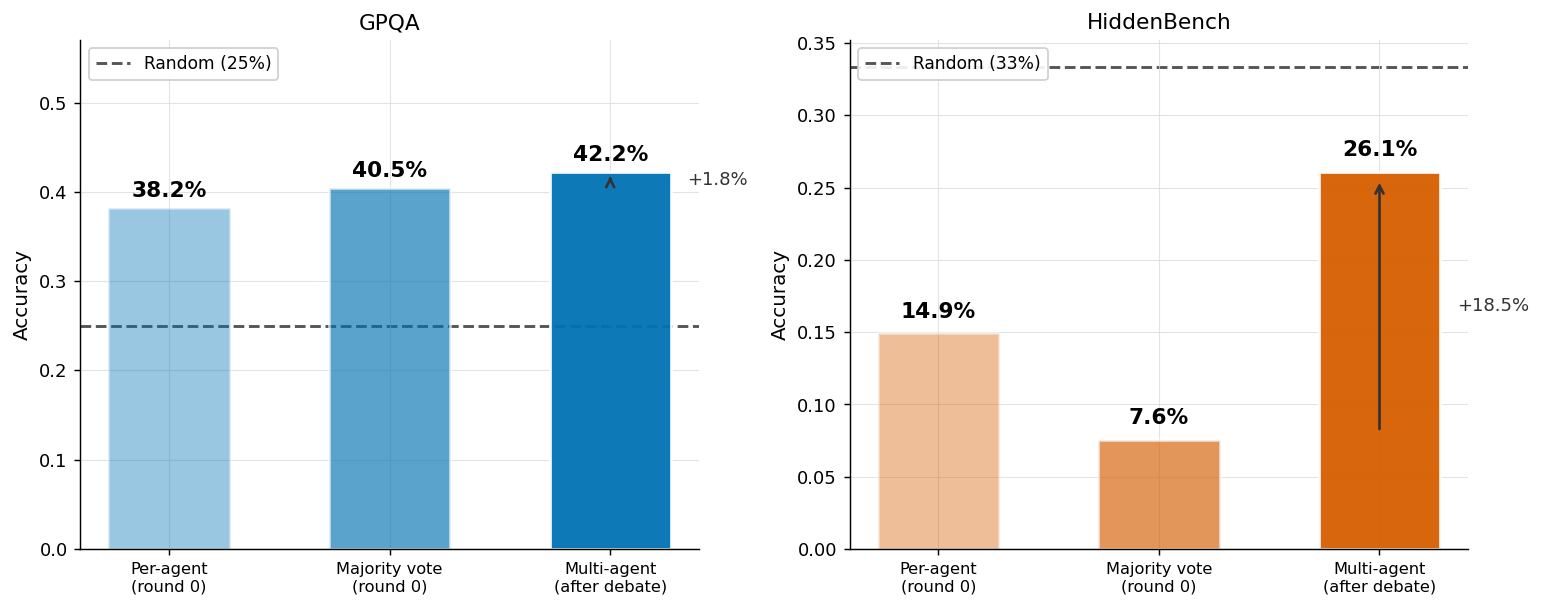

fig1 saved -> ../../thesis/plots/general/fig1_single_vs_multi.png


In [5]:
# Fig 1 — single vs multi (per-agent / majority / debate) with random line
fig, axes = plt.subplots(1, 2, figsize=FIGSIZES['twopanel'])
bar_labels = ['Per-agent\n(round 0)', 'Majority vote\n(round 0)', 'Multi-agent\n(after debate)']

for col, ds in enumerate(DATASETS):
    ax  = axes[col]
    sub = reps_df[reps_df['dataset'] == ds]
    vals = [sub['per_agent_correct'].mean(), sub['init_correct'].mean(), sub['correct'].mean()]
    alphas = [0.40, 0.65, 0.95]
    for i, (val, lbl, alph) in enumerate(zip(vals, bar_labels, alphas)):
        ax.bar(i, val, color=DS_COLORS[ds], alpha=alph, width=0.55,
               edgecolor='white', linewidth=1.5)
        ax.text(i, val + 0.008, f'{val:.1%}', ha='center', va='bottom',
                fontweight='bold', fontsize=12)
    _ch = 0.25 if ds == 'gpqa' else 1/3
    ax.axhline(_ch, color='#555', linestyle='--', linewidth=1.6, label=f'Random ({_ch:.0%})', zorder=0)
    delta = vals[2] - vals[1]
    y_lo = min(vals[1], vals[2]) + 0.005
    y_hi = max(vals[1], vals[2]) - 0.005
    ax.annotate('', xy=(2, y_hi), xytext=(2, y_lo),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
    ax.text(2.35, (vals[1] + vals[2]) / 2, f'{delta:+.1%}', ha='left', va='center',
            fontsize=10, color='#333')
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_ylabel('Accuracy'); ax.set_ylim(0, max(vals) * 1.35)
    ax.set_title(DS_LABELS[ds]); ax.legend(loc='upper left'); ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(EXPORT / 'fig1_single_vs_multi.png', bbox_inches='tight')
plt.show()
print('fig1 saved ->', EXPORT / 'fig1_single_vs_multi.png')

---
## Topology (tab:perf:topology) — task-level tests (ledger #8, M2)

In [6]:
from src.metrics.stats_utils import (task_paired_wilcoxon, task_friedman,
                                     cluster_bootstrap_diff, bh_fdr)

# Pooled (rep-level) accuracy + mean rounds per topology -> table body cells.
# --- sec:results:perf L169-173 tab:perf:topology accuracy + rounds + deltas ---
print('=== tab:perf:topology  (pooled over W, n=5,250 reps/cell) ===')
THESIS_TOPO = {  # (acc_fc, acc_star, rounds_fc, rounds_star)
    'gpqa':        (0.423, 0.422, 3.79, 4.30),
    'hiddenbench': (0.264, 0.258, 4.89, 6.63),
}
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    a_fc = sub[sub.topology=='fc']['correct'].mean()
    a_st = sub[sub.topology=='star']['correct'].mean()
    r_fc = sub[sub.topology=='fc']['n_rounds'].mean()
    r_st = sub[sub.topology=='star']['n_rounds'].mean()
    taf, tas, trf, trs = THESIS_TOPO[ds]
    print(f'  {DS_LABELS[ds]}')
    print(f'    acc    fc computed={a_fc:.3f} thesis={taf:.3f}  star computed={a_st:.3f} thesis={tas:.3f}  '
          f'delta(acc)={100*(a_st-a_fc):+.1f}pp')
    print(f'    rounds fc computed={r_fc:.3f} thesis={trf:.2f}  star computed={r_st:.3f} thesis={trs:.2f}  '
          f'delta(rounds fc-star)={r_fc-r_st:+.2f}')

print()
# --- sec:results:perf L180-183,196 topology accuracy: task-paired Wilcoxon + bootstrap CI ---
# ledger #8: rep-level MWU on 0/1 is wrong; use task-paired Wilcoxon (task = mean over W).
cell_lvl = (reps_df.groupby(['dataset', 'topology', 'W', 'qid'])
            .agg(accuracy=('correct', 'mean'), rounds=('n_rounds', 'mean')).reset_index())
THESIS_TOPO_ACC_P = {'gpqa': 0.92, 'hiddenbench': 0.60}       # tex caption/text values
LEDGER_TOPO_ACC_P = {'gpqa': 0.903, 'hiddenbench': 0.151}     # ledger #8 corrected
THESIS_TOPO_CI    = {'gpqa': (-0.12, 0.12), 'hiddenbench': (-0.07, 0.08)}
print('=== Topology ACCURACY task-paired Wilcoxon (task = mean over W, n=50) ===')
for ds in DATASETS:
    t = cell_lvl[cell_lvl.dataset==ds].groupby(['topology','qid'])['accuracy'].mean().reset_index()
    piv = t.pivot(index='qid', columns='topology', values='accuracy').dropna()
    stat, p, md_, n = task_paired_wilcoxon(piv['fc'].values, piv['star'].values)
    obs, lo, hi, pb = cluster_bootstrap_diff(piv['fc'].values, piv['star'].values)
    tlo, thi = THESIS_TOPO_CI[ds]
    m_p = 'MATCH' if abs(p - LEDGER_TOPO_ACC_P[ds]) < 0.01 else 'CHECK'
    print(f'  {DS_LABELS[ds]:12s} fc={piv["fc"].mean():.3f} star={piv["star"].mean():.3f} '
          f'delta(fc-star)={obs:+.3f} CI[{lo:+.3f},{hi:+.3f}]')
    print(f'    Wilcoxon p computed={p:.4f}  thesis_says={THESIS_TOPO_ACC_P[ds]}  '
          f'ledger#8_says={LEDGER_TOPO_ACC_P[ds]}  {m_p}')
    print(f'    bootstrap CI computed=[{lo:+.3f},{hi:+.3f}]  thesis_says=[{tlo:+.2f},{thi:+.2f}]')

print()
# --- sec:results:perf L184-185,199-204 topology ROUNDS task-paired Wilcoxon (p<0.001) ---
print('=== Topology ROUNDS task-paired Wilcoxon (task = mean over W, n=50) ===')
for ds in DATASETS:
    t = cell_lvl[cell_lvl.dataset==ds].groupby(['topology','qid'])['rounds'].mean().reset_index()
    piv = t.pivot(index='qid', columns='topology', values='rounds').dropna()
    stat, p, md_, n = task_paired_wilcoxon(piv['fc'].values, piv['star'].values)
    print(f'  {DS_LABELS[ds]:12s} fc={piv["fc"].mean():.3f} star={piv["star"].mean():.3f} '
          f'delta(fc-star)={piv["fc"].mean()-piv["star"].mean():+.3f}  Wilcoxon p={p:.2e}  '
          f'(thesis_says p<0.001)')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== tab:perf:topology  (pooled over W, n=5,250 reps/cell) ===
  GPQA
    acc    fc computed=0.423 thesis=0.423  star computed=0.422 thesis=0.422  delta(acc)=-0.1pp
    rounds fc computed=3.793 thesis=3.79  star computed=4.296 thesis=4.30  delta(rounds fc-star)=-0.50
  HiddenBench
    acc    fc computed=0.264 thesis=0.264  star computed=0.258 thesis=0.258  delta(acc)=-0.5pp
    rounds fc computed=4.891 thesis=4.89  star computed=6.628 thesis=6.63  delta(rounds fc-star)=-1.74

=== Topology ACCURACY task-paired Wilcoxon (task = mean over W, n=50) ===
  GPQA         fc=0.423 star=0.422 delta(fc-star)=+0.001 CI[-0.121,+0.122]
    Wilcoxon p computed=0.9199  thesis_says=0.92  ledger#8_says=0.903  CHECK
    bootstrap CI computed=[-0.121,+0.122]  thesis_says=[-0.12,+0.12]


  HiddenBench  fc=0.264 star=0.258 delta(fc-star)=+0.005 CI[-0.070,+0.082]
    Wilcoxon p computed=0.6041  thesis_says=0.6  ledger#8_says=0.151  CHECK
    bootstrap CI computed=[-0.070,+0.082]  thesis_says=[-0.07,+0.08]

=== Topology ROUNDS task-paired Wilcoxon (task = mean over W, n=50) ===
  GPQA         fc=3.793 star=4.296 delta(fc-star)=-0.503  Wilcoxon p=1.02e-09  (thesis_says p<0.001)
  HiddenBench  fc=4.891 star=6.628 delta(fc-star)=-1.737  Wilcoxon p=7.56e-10  (thesis_says p<0.001)


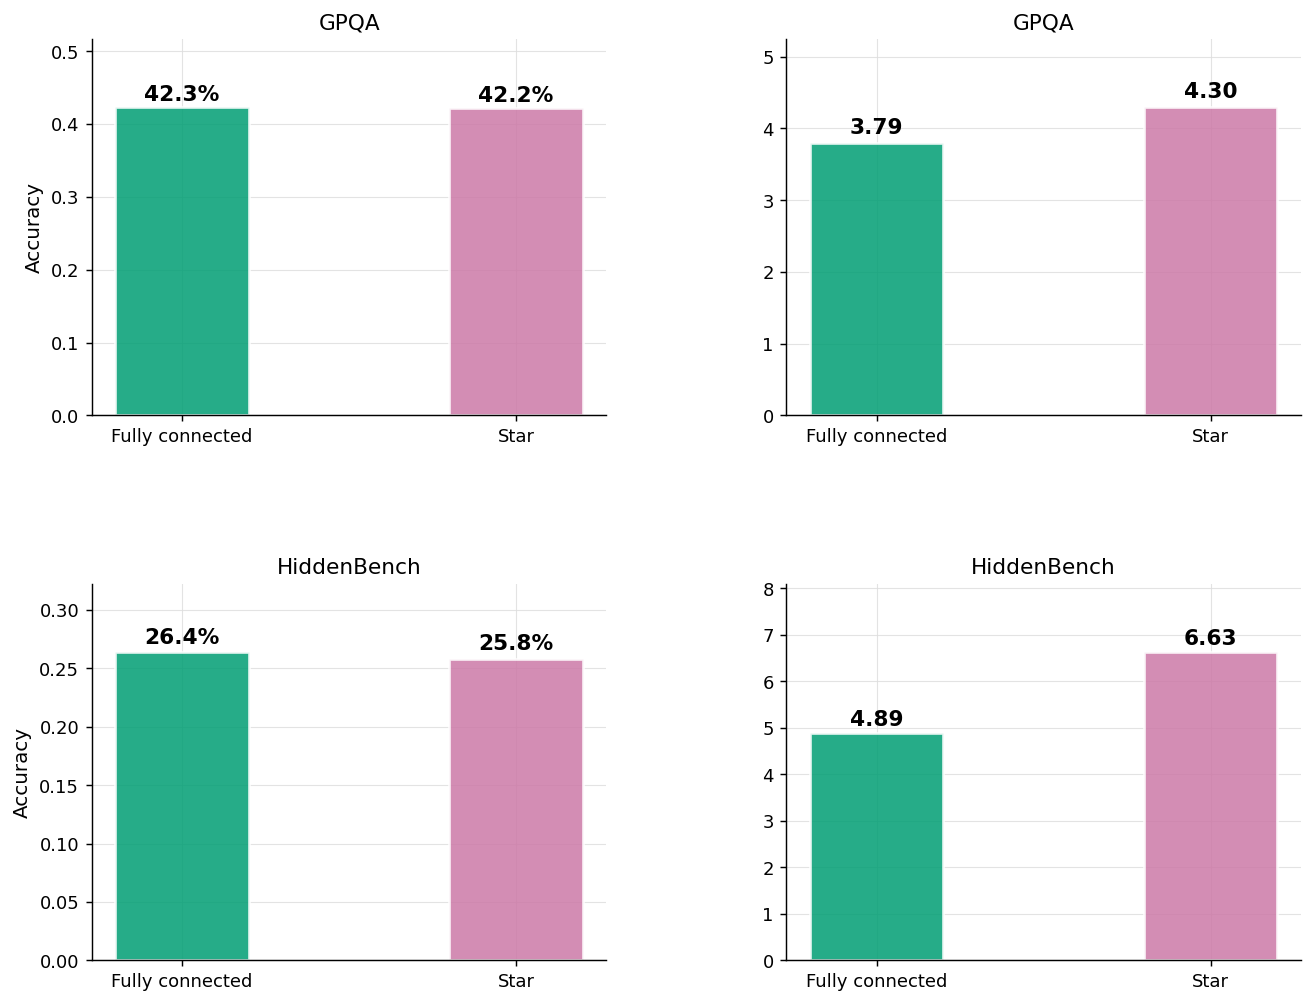

fig2 saved -> ../../thesis/plots/general/fig2_topology.png


In [7]:
# Fig 2 — topology: accuracy + mean rounds, 2x2
fig, axes = plt.subplots(2, 2, figsize=FIGSIZES['grid2x2'])
fig.subplots_adjust(hspace=0.45, wspace=0.35)
metrics = [('correct', 'Accuracy', True), ('n_rounds', 'Mean rounds to consensus', False)]

for col, (metric, ylabel, as_pct) in enumerate(metrics):
    for row, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = reps_df[reps_df['dataset'] == ds]
        means  = [sub[sub['topology'] == t][metric].mean() for t in TOPOS]
        colors = [T_COLORS[t] for t in TOPOS]
        bars = ax.bar([T_LABELS[t] for t in TOPOS], means, color=colors,
                      alpha=0.85, width=0.4, edgecolor='white', linewidth=1.5)
        for bar, val in zip(bars, means):
            label = f'{val:.1%}' if as_pct else f'{val:.2f}'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.004 if as_pct else 0.08),
                    label, ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.set_title(DS_LABELS[ds]); ax.set_ylabel(ylabel if col == 0 else '')
        ax.set_ylim(0, max(means) * 1.22); ax.set_axisbelow(True)

fig.savefig(EXPORT / 'fig2_topology.png', bbox_inches='tight')
plt.show()
print('fig2 saved ->', EXPORT / 'fig2_topology.png')

---
## Memory window (fig:perf:memory_window) — task-blocked Friedman (ledger #5, M15)

In [8]:
# --- sec:results:perf L224-238 memory-window ACCURACY: task-blocked Friedman ---
# ledger #5/#15: "all p>=0.10 (ns)" is FALSE. HB/fc Friedman p=0.019 (significant);
# others 0.175/0.281/0.679. BH-FDR across the 4 cells -> HB/fc q=0.076 (does not survive).
THESIS_ACC_FRIED = {('gpqa','fc'):0.22, ('gpqa','star'):0.53,
                    ('hiddenbench','fc'):0.017, ('hiddenbench','star'):0.032}
print('=== Memory-window ACCURACY task-blocked Friedman (unit=task, n=50) ===')
acc_labs, acc_ps = [], []
for ds in DATASETS:
    for topo in TOPOS:
        s = cell_lvl[(cell_lvl.dataset==ds) & (cell_lvl.topology==topo)]
        piv = s.pivot(index='qid', columns='W', values='accuracy').dropna()
        stat, p, n = task_friedman(*[piv[w].values for w in W_VALUES])
        t = THESIS_ACC_FRIED[(ds, topo)]
        m = 'MATCH' if abs(p - t) < 0.006 else 'MISMATCH'
        acc_labs.append(f'{DS_LABELS[ds]}/{topo}'); acc_ps.append(p)
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  W1={piv[1].mean():.3f} W2={piv[2].mean():.3f} '
              f'W5={piv[5].mean():.3f}  Friedman p computed={p:.4f} thesis_says={t}  {m}')

q, rej = bh_fdr(acc_ps)
print()
print('  BH-FDR across the 4 accuracy cells (alpha=0.05):')
for l, p, qq, r in zip(acc_labs, acc_ps, q, rej):
    tag = 'HB/fc q thesis_says=0.076' if l == 'HiddenBench/fc' else ''
    print(f'    {l:18s} p={p:.4f}  q={qq:.4f}  {"survives" if r else "ns"}  {tag}')

=== Memory-window ACCURACY task-blocked Friedman (unit=task, n=50) ===
  GPQA         fc     W1=0.414 W2=0.431 W5=0.424  Friedman p computed=0.2199 thesis_says=0.22  MATCH
  GPQA         star   W1=0.418 W2=0.425 W5=0.422  Friedman p computed=0.5264 thesis_says=0.53  MATCH
  HiddenBench  fc     W1=0.252 W2=0.282 W5=0.258  Friedman p computed=0.0165 thesis_says=0.017  MATCH
  HiddenBench  star   W1=0.245 W2=0.266 W5=0.264  Friedman p computed=0.0319 thesis_says=0.032  MATCH

  BH-FDR across the 4 accuracy cells (alpha=0.05):
    GPQA/fc            p=0.2199  q=0.2931  ns  
    GPQA/star          p=0.5264  q=0.5264  ns  
    HiddenBench/fc     p=0.0165  q=0.0639  ns  HB/fc q thesis_says=0.076
    HiddenBench/star   p=0.0319  q=0.0639  ns  


In [9]:
# --- sec:results:perf L241-253 memory-window ROUNDS: task-blocked Friedman + W-cell means ---
THESIS_RND_FRIED = {('gpqa','fc'):0.013, ('gpqa','star'):0.68,
                    ('hiddenbench','fc'):0.001, ('hiddenbench','star'):0.001}
print('=== Memory-window ROUNDS task-blocked Friedman (unit=task, n=50) ===')
for ds in DATASETS:
    for topo in TOPOS:
        s = cell_lvl[(cell_lvl.dataset==ds) & (cell_lvl.topology==topo)]
        piv = s.pivot(index='qid', columns='W', values='rounds').dropna()
        stat, p, n = task_friedman(*[piv[w].values for w in W_VALUES])
        t = THESIS_RND_FRIED[(ds, topo)]
        note = f'thesis_says~{t}' if t >= 0.01 else 'thesis_says p<0.001'
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  W1={piv[1].mean():.3f} W2={piv[2].mean():.3f} '
              f'W5={piv[5].mean():.3f}  Friedman p={p:.4f}  {note}')

print()
# rep-level mean rounds per W cell (values quoted in prose L243-253 / appendix table)
print('=== Mean rounds per (dataset, topology, W) ===')
mr = reps_df.groupby(['dataset','topology','W'])['n_rounds'].mean().round(3)
print(mr.to_string())

=== Memory-window ROUNDS task-blocked Friedman (unit=task, n=50) ===
  GPQA         fc     W1=3.870 W2=3.678 W5=3.830  Friedman p=0.0172  thesis_says~0.013
  GPQA         star   W1=4.292 W2=4.231 W5=4.364  Friedman p=0.5312  thesis_says~0.68
  HiddenBench  fc     W1=5.179 W2=4.708 W5=4.787  Friedman p=0.0000  thesis_says p<0.001
  HiddenBench  star   W1=7.132 W2=6.481 W5=6.272  Friedman p=0.0000  thesis_says p<0.001

=== Mean rounds per (dataset, topology, W) ===
dataset      topology  W
gpqa         fc        1    3.870
                       2    3.678
                       5    3.830
             star      1    4.292
                       2    4.231
                       5    4.364
hiddenbench  fc        1    5.179
                       2    4.708
                       5    4.787
             star      1    7.132
                       2    6.481
                       5    6.272


In [ ]:
# Fig 3 — memory window: accuracy + efficiency, lines per topology
fig, axes = plt.subplots(2, 2, figsize=FIGSIZES['grid2x2'])
fig.subplots_adjust(hspace=0.45, wspace=0.38)
metrics = [('correct', 'Accuracy', True),
           ('n_rounds', 'Mean rounds to consensus\n(efficiency)', False)]

for col, (metric, ylabel, as_pct) in enumerate(metrics):
    for row, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = reps_df[reps_df['dataset'] == ds]
        series = {}
        for topo in TOPOS:
            means = [sub[(sub['topology']==topo) & (sub['W']==w)][metric].mean() for w in W_VALUES]
            series[topo] = means
            ax.plot(W_VALUES, means, marker='o', linewidth=2, markersize=8,
                    color=T_COLORS[topo], label=T_LABELS[topo])
        # place each label above the higher line / below the lower one so they never collide
        for i, w in enumerate(W_VALUES):
            higher = max(TOPOS, key=lambda t: series[t][i])
            for topo in TOPOS:
                m = series[topo][i]
                up = (topo == higher)
                lbl = f'{m:.1%}' if as_pct else f'{m:.2f}'
                ax.annotate(lbl, (w, m), textcoords='offset points',
                            xytext=(0, 12 if up else -16),
                            ha='center', va='bottom' if up else 'top',
                            fontsize=9, fontweight='bold', color=T_COLORS[topo])
        lo = min(min(v) for v in series.values()); hi = max(max(v) for v in series.values())
        pad = (hi - lo) * 0.45 + (0.014 if as_pct else 0.16)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlim(W_VALUES[0] - 0.5, W_VALUES[-1] + 0.5)
        ax.set_xticks(W_VALUES); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_xlabel('Memory window'); ax.set_ylabel(ylabel)
        ax.set_title(DS_LABELS[ds])
        if row == 0 and col == 0:
            ax.legend()
        ax.set_axisbelow(True)

fig.savefig(EXPORT / 'fig3_memory_window.png', bbox_inches='tight')
plt.show()
print('fig3 saved ->', EXPORT / 'fig3_memory_window.png')

---
## Round distributions & cap rates (fig:perf:round_dist)

In [11]:
# --- sec:results:perf L282-300 cap-reach rates per config ---
print('=== Fraction hitting hard cap T=15 per config ===')
for ds in DATASETS:
    caps = []
    for topo in TOPOS:
        for w in W_VALUES:
            sub = reps_df[(reps_df.dataset==ds)&(reps_df.topology==topo)&(reps_df.W==w)]
            p = (sub['n_rounds'] == 15).mean()
            caps.append((topo, w, p))
    print(f'  {DS_LABELS[ds]}')
    for topo, w, p in caps:
        print(f'    {topo:5s} W={w}  p_cap={100*p:.1f}%')
    fc_caps   = [100*p for topo, w, p in caps if topo == 'fc']
    star_caps = [100*p for topo, w, p in caps if topo == 'star']
    print(f'    -> all configs: {min(100*p for _,_,p in caps):.1f}%-{max(100*p for _,_,p in caps):.1f}%  '
          f'fc: {min(fc_caps):.1f}%-{max(fc_caps):.1f}%  star: {min(star_caps):.1f}%-{max(star_caps):.1f}%')
print('  thesis_says: GPQA all <=1.6%; HiddenBench 1.2-14.3%; HB star 11.0-14.3%; HB fc 1.2-3.3%')

=== Fraction hitting hard cap T=15 per config ===
  GPQA
    fc    W=1  p_cap=0.2%
    fc    W=2  p_cap=0.2%
    fc    W=5  p_cap=0.4%
    star  W=1  p_cap=1.0%
    star  W=2  p_cap=1.0%
    star  W=5  p_cap=1.6%
    -> all configs: 0.2%-1.6%  fc: 0.2%-0.4%  star: 1.0%-1.6%
  HiddenBench
    fc    W=1  p_cap=2.5%
    fc    W=2  p_cap=1.0%
    fc    W=5  p_cap=2.0%
    star  W=1  p_cap=13.3%
    star  W=2  p_cap=11.2%
    star  W=5  p_cap=10.7%
    -> all configs: 1.0%-13.3%  fc: 1.0%-2.5%  star: 10.7%-13.3%
  thesis_says: GPQA all <=1.6%; HiddenBench 1.2-14.3%; HB star 11.0-14.3%; HB fc 1.2-3.3%


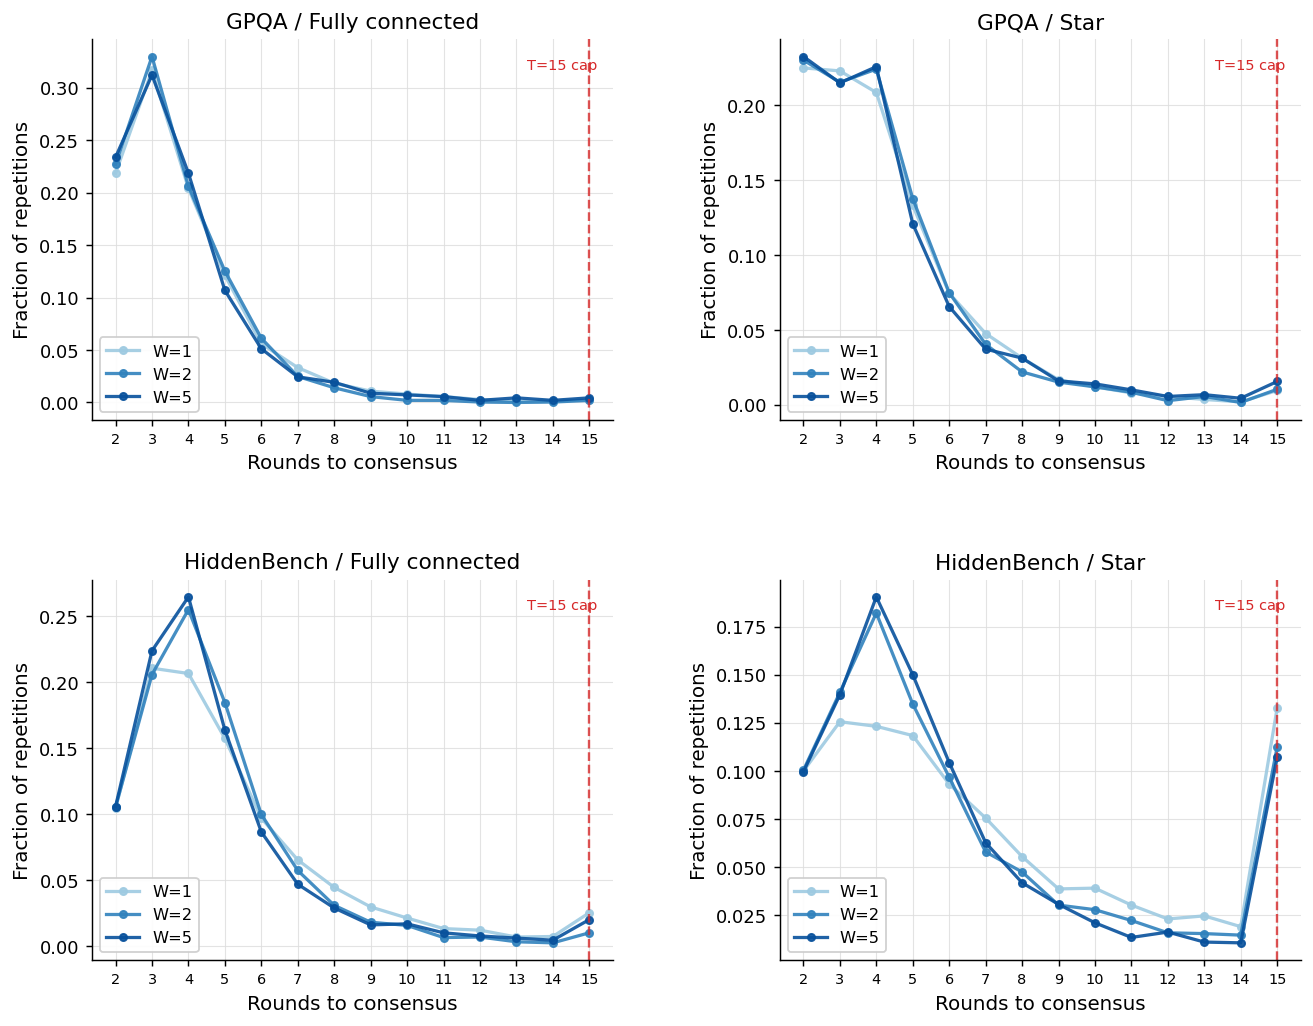

fig4 saved -> ../../thesis/plots/general/fig4_round_distribution.png


In [12]:
# Fig 4 — round-count distributions, 2x2, one line per W
R_RANGE = range(2, 16)
fig, axes = plt.subplots(2, 2, figsize=FIGSIZES['grid2x2'])
fig.subplots_adjust(hspace=0.42, wspace=0.32)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = reps_df[(reps_df['dataset']==ds) & (reps_df['topology']==topo)]
        for w in W_VALUES:
            vals  = sub[sub['W']==w]['n_rounds'].values
            fracs = np.array([(vals == r).mean() for r in R_RANGE])
            ax.plot(list(R_RANGE), fracs, marker='o', linewidth=1.8, markersize=4,
                    color=W_COLORS[w], label=f'W={w}', alpha=0.9)
        ax.axvline(15, color='#d62728', linestyle='--', linewidth=1.3, alpha=0.8)
        ax.text(0.97, 0.95, 'T=15 cap', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#d62728')
        ax.set_xticks(list(R_RANGE)); ax.set_xticklabels([str(r) for r in R_RANGE], fontsize=8)
        ax.set_xlabel('Rounds to consensus'); ax.set_ylabel('Fraction of repetitions')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=9); ax.set_axisbelow(True)

fig.savefig(EXPORT / 'fig4_round_distribution.png', bbox_inches='tight')
plt.show()
print('fig4 saved ->', EXPORT / 'fig4_round_distribution.png')

---
## Rounds vs accuracy (fig:app:perf:rounds_acc, app:perf:rounds_acc)

In [13]:
# --- sec:results:perf L306-316 rounds-vs-accuracy buckets (min n=20, all configs pooled) ---
print('=== Accuracy by rounds-to-consensus bucket (min n=20 obs) ===')
for ds in DATASETS:
    sub = reps_df[reps_df['dataset'] == ds]
    print(f'  {DS_LABELS[ds]}')
    for r_val in sorted(sub['n_rounds'].unique()):
        bucket = sub[sub['n_rounds'] == r_val]
        if len(bucket) >= 20:
            print(f'    rounds={r_val:2d}  n={len(bucket):4d}  acc={bucket["correct"].mean():.3f}')

# thesis-cited specific buckets
g = reps_df[reps_df.dataset=='gpqa']
h = reps_df[reps_df.dataset=='hiddenbench']
g34 = g[g.n_rounds.isin([3, 4])]['correct'].mean()
print()
print('  --- thesis-cited buckets ---')
print(f'  GPQA round2={g[g.n_rounds==2]["correct"].mean():.3f} (thesis 0.361)  '
      f'rounds3-4 pooled={g34:.3f} (thesis 0.471)')
print(f'  HiddenBench round2={h[h.n_rounds==2]["correct"].mean():.3f} (thesis 0.064)  '
      f'round3={h[h.n_rounds==3]["correct"].mean():.3f} (thesis 0.238)  '
      f'round4={h[h.n_rounds==4]["correct"].mean():.3f} (thesis 0.317)  '
      f'round5={h[h.n_rounds==5]["correct"].mean():.3f} (thesis 0.331)')

=== Accuracy by rounds-to-consensus bucket (min n=20 obs) ===
  GPQA
    rounds= 2  n=3415  acc=0.452
    rounds= 3  n=4027  acc=0.461
    rounds= 4  n=3216  acc=0.416
    rounds= 5  n=1862  acc=0.378
    rounds= 6  n= 958  acc=0.354
    rounds= 7  n= 519  acc=0.376
    rounds= 8  n= 340  acc=0.371
    rounds= 9  n= 183  acc=0.383
    rounds=10  n= 138  acc=0.312
    rounds=11  n=  99  acc=0.384
    rounds=12  n=  48  acc=0.396
    rounds=13  n=  54  acc=0.389
    rounds=14  n=  30  acc=0.300
    rounds=15  n= 111  acc=0.315
  HiddenBench
    rounds= 2  n=1538  acc=0.025
    rounds= 3  n=2614  acc=0.187
    rounds= 4  n=3053  acc=0.305
    rounds= 5  n=2271  acc=0.324
    rounds= 6  n=1443  acc=0.333
    rounds= 7  n= 914  acc=0.342
    rounds= 8  n= 623  acc=0.271
    rounds= 9  n= 409  acc=0.337
    rounds=10  n= 355  acc=0.324
    rounds=11  n= 240  acc=0.279
    rounds=12  n= 205  acc=0.332
    rounds=13  n= 169  acc=0.302
    rounds=14  n= 147  acc=0.204
    rounds=15  n=1019  acc

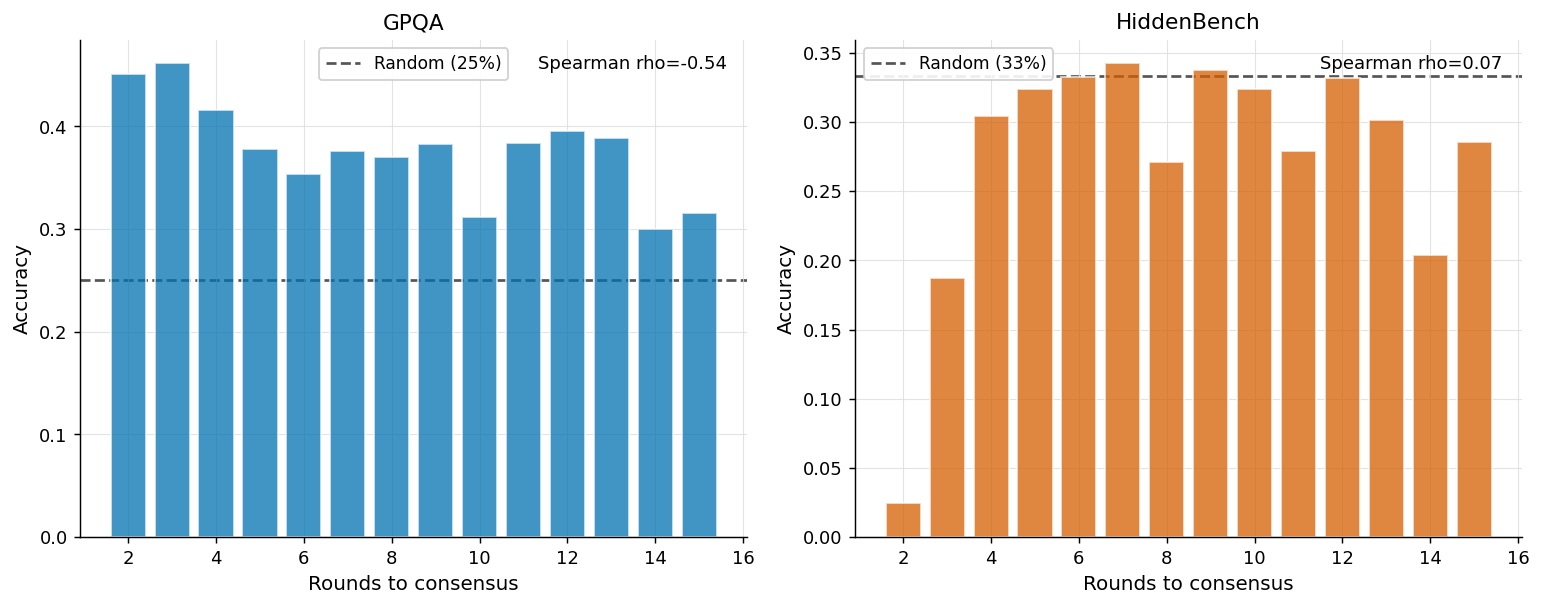

fig5 saved -> ../../thesis/plots/general/fig5_rounds_vs_accuracy.png


In [14]:
# Fig 5 — rounds vs accuracy, 1x2 (GPQA / HiddenBench), min n=20
fig, axes = plt.subplots(1, 2, figsize=FIGSIZES['twopanel'])

for col, ds in enumerate(DATASETS):
    ax  = axes[col]
    sub = reps_df[reps_df['dataset'] == ds]
    r_vals, acc_vals = [], []
    for r_val in sorted(sub['n_rounds'].unique()):
        bucket = sub[sub['n_rounds'] == r_val]
        if len(bucket) >= 20:
            r_vals.append(r_val); acc_vals.append(bucket['correct'].mean())
    ax.bar(r_vals, acc_vals, color=DS_COLORS[ds], alpha=0.75, edgecolor='white', linewidth=1)
    _ch = 0.25 if ds == 'gpqa' else 1/3
    ax.axhline(_ch, color='#555', linestyle='--', linewidth=1.5, label=f'Random ({_ch:.0%})', zorder=0)
    r, p = sp_stats.spearmanr(r_vals, acc_vals)
    ax.text(0.97, 0.97, f'Spearman rho={r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10)
    ax.set_xlabel('Rounds to consensus'); ax.set_ylabel('Accuracy')
    ax.set_title(DS_LABELS[ds]); ax.legend(); ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(EXPORT / 'fig5_rounds_vs_accuracy.png', bbox_inches='tight')
plt.show()
print('fig5 saved ->', EXPORT / 'fig5_rounds_vs_accuracy.png')

---
## Appendix full configuration table (tab:app:perf:configs)

In [15]:
# --- app:perf:configs tab:app:perf:configs: accuracy, mean rounds, p_cap, mean flips per 12 configs ---
print('=== tab:app:perf:configs (R=50, 50 tasks, n=2,500 reps/cell) ===')
summary = (reps_df.groupby(['dataset', 'topology', 'W'])
           .agg(accuracy=('correct', 'mean'),
                mean_rounds=('n_rounds', 'mean'),
                p_cap=('n_rounds', lambda x: (x == 15).mean()),
                mean_flips=('vote_flips', 'mean'))
           .round(4))
print(summary.to_string())
print()

# printed as the LaTeX table cells, with thesis comparison
THESIS_CFG = {  # (acc, rounds, p_cap, flips)
    ('gpqa','fc',1):(0.414,3.87,0.002,2.98), ('gpqa','fc',2):(0.431,3.68,0.002,2.90),
    ('gpqa','fc',5):(0.424,3.83,0.004,2.91), ('gpqa','star',1):(0.418,4.29,0.010,3.11),
    ('gpqa','star',2):(0.425,4.23,0.010,3.77), ('gpqa','star',5):(0.422,4.36,0.016,3.43),
    ('hiddenbench','fc',1):(0.252,5.18,0.025,4.27), ('hiddenbench','fc',2):(0.282,4.71,0.010,3.92),
    ('hiddenbench','fc',5):(0.258,4.79,0.020,3.86), ('hiddenbench','star',1):(0.245,7.13,0.133,4.82),
    ('hiddenbench','star',2):(0.266,6.48,0.112,5.22), ('hiddenbench','star',5):(0.264,6.27,0.107,5.12),
}
print('=== per-config computed vs thesis (tab:app:perf:configs) ===')
for (ds, topo, w), (tacc, trnd, tcap, tflip) in THESIS_CFG.items():
    r = summary.loc[(ds, topo, w)]
    ok = (abs(r['accuracy']-tacc)<0.002 and abs(r['mean_rounds']-trnd)<0.02
          and abs(r['p_cap']-tcap)<0.002 and abs(r['mean_flips']-tflip)<0.02)
    print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
          f'acc={r["accuracy"]:.3f}/{tacc}  rounds={r["mean_rounds"]:.2f}/{trnd}  '
          f'p_cap={r["p_cap"]:.3f}/{tcap}  flips={r["mean_flips"]:.2f}/{tflip}  '
          f'{"MATCH" if ok else "MISMATCH"}')

=== tab:app:perf:configs (R=50, 50 tasks, n=2,500 reps/cell) ===
                        accuracy  mean_rounds   p_cap  mean_flips
dataset     topology W                                           
gpqa        fc       1    0.4144       3.8700  0.0024      2.9764
                     2    0.4308       3.6780  0.0020      2.8968
                     5    0.4240       3.8304  0.0044      2.9144
            star     1    0.4184       4.2920  0.0096      3.1076
                     2    0.4252       4.2312  0.0104      3.7660
                     5    0.4220       4.3644  0.0156      3.4348
hiddenbench fc       1    0.2516       5.1788  0.0252      4.2716
                     2    0.2820       4.7080  0.0100      3.9224
                     5    0.2576       4.7868  0.0200      3.8592
            star     1    0.2448       7.1320  0.1328      4.8224
                     2    0.2656       6.4808  0.1124      5.2220
                     5    0.2644       6.2720  0.1072      5.1172

=== per-co